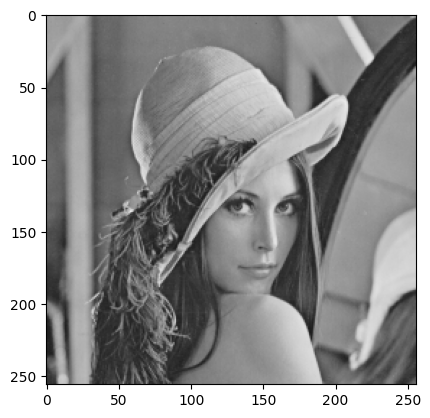

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

image = cv2.imread("lena_translate.png")
plt.imshow(image)
plt.show()

Task 1

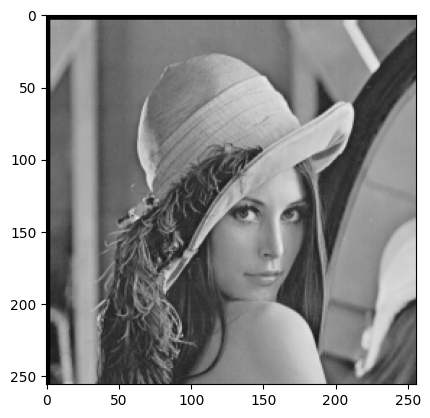

In [2]:
def shift_image(image,tx,ty):
    translation_matrix = np.array([[1, 0, tx],
                                   [0, 1, ty],
                                   [0, 0, 1]])
    h, w, c = image.shape
    translated_image = np.zeros_like(image)
    translation_matrix_inv = np.linalg.inv(translation_matrix)
    for y in range(h):
        for x in range(w):
            pixel = np.array([x, y, 1])
            src_pixel = translation_matrix_inv @ pixel
            src_x, src_y = src_pixel[0], src_pixel[1]
            translated_image[y, x] = image[int(src_y), int(src_x)] if 0 <= int(src_x) < w and 0 <= int(src_y) < h else 0
    return translated_image

trans_img = shift_image(image,3.75,4.3)
plt.imshow(trans_img)
plt.show()

256 256


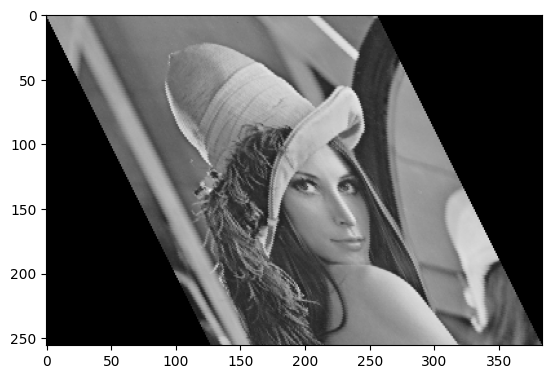

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def shear_no_crop(image, shx=0.0, shy=0.0):
    h, w, c = image.shape
    print(h,w)

    # Forward shear matrix
    S = np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ])

    # Image corners
    corners = np.array([
        [0,   0,   1],
        [w-1, 0,   1],
        [0,   h-1, 1],
        [w-1, h-1, 1]
    ])

    # Transform corners
    warped = (S @ corners.T).T
    xs, ys = warped[:,0], warped[:,1]

    min_x, max_x = int(np.floor(xs.min())), int(np.ceil(xs.max()))
    min_y, max_y = int(np.floor(ys.min())), int(np.ceil(ys.max()))

    new_w = max_x - min_x + 1
    new_h = max_y - min_y + 1

    # Translation to keep coords positive
    T = np.array([
        [1, 0, -min_x],
        [0, 1, -min_y],
        [0, 0, 1]
    ])

    S_total = T @ S
    S_inv = np.linalg.inv(S_total)

    # Output image
    output = np.zeros((new_h, new_w, c), dtype=image.dtype)

    for y in range(new_h):
        for x in range(new_w):
            src = S_inv @ np.array([x, y, 1])
            sx, sy = int(src[0]), int(src[1])
            if 0 <= sx < w and 0 <= sy < h:
                output[y, x] = image[sy, sx]

    return output
sheared_image = shear_no_crop(image, shx=0.5, shy=0)
plt.imshow(sheared_image)   
plt.show()

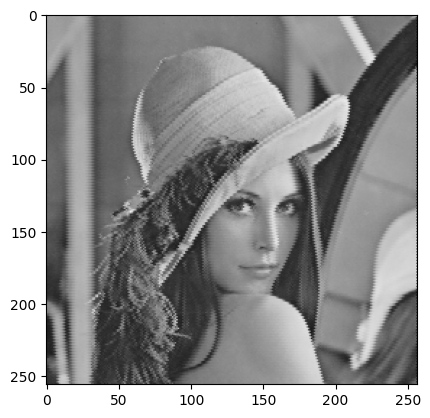

In [19]:
def restore_shear(image, shx, shy):
    shear_matrix = np.array([[1, shx, 0],
                             [shy, 1, 0],
                             [0, 0, 1]])
    shear_matrix_inv = np.linalg.inv(shear_matrix)
    h, w, c = image.shape
    restored_image = np.zeros_like(image)
    for y in range(h):
        for x in range(w):
            pixel = np.array([x, y, 1])
            src_pixel = shear_matrix @ pixel
            src_x, src_y = src_pixel[0], src_pixel[1]
            restored_image[y, x] = image[int(src_y), int(src_x)] if 0 <= int(src_x) < w and 0 <= int(src_y) < h else 0
    restored_image = cv2.resize(restored_image, (image.shape[1], image.shape[0]))
    return restored_image
import numpy as np

def crop_black_padding(image, threshold=1):
    """
    Crops black padding from an image.
    threshold: pixel values <= threshold are treated as black
    """
    if image.ndim == 3:  # RGB
        mask = np.any(image > threshold, axis=2)
    else:  # grayscale
        mask = image > threshold

    coords = np.argwhere(mask)

    if coords.size == 0:
        return image  # image is fully black

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return image[y0:y1, x0:x1]

restored_img = restore_shear(sheared_image,0.5,0)
restored_img = crop_black_padding(restored_img)
plt.imshow(restored_img)
plt.show()

Task 2

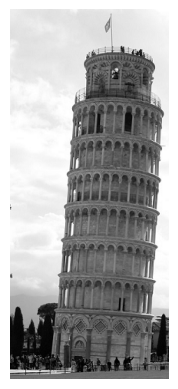

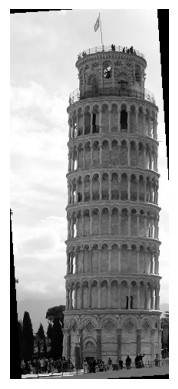

In [18]:

def rotate(image, degrees):
    h, w = image.shape[:2]
    cx, cy = w / 2, h / 2

    theta = np.deg2rad(degrees)

    R = np.array([                                    #Rotation matrix
        [ np.cos(theta),  np.sin(theta), 0],
        [-np.sin(theta),  np.cos(theta), 0],
        [ 0,              0,             1]
    ])

    T_to_center = np.array([                          #Translation to center
        [1, 0, -cx], 
        [0, 1, -cy],
        [0, 0,  1]
    ])

    T_back = np.array([ 
        [1, 0, cx],
        [0, 1, cy],
        [0, 0,  1]
    ])
    M = T_back @ R @ T_to_center
    M_inv = np.linalg.inv(M)

    rotated_img = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            pixel = np.array([j, i, 1])
            src = M_inv @ pixel
            x, y = int(src[0]), int(src[1])

            if 0 <= x < w and 0 <= y < h:
                rotated_img[i, j] = image[y, x]

    return rotated_img

image=cv2.imread("pisa_rotate.png")
rotated_img = rotate(image, 3.8)
plt.imshow(image)
plt.axis("off")
plt.show()
plt.imshow(rotated_img)
plt.axis("off")
plt.show()


Task 3

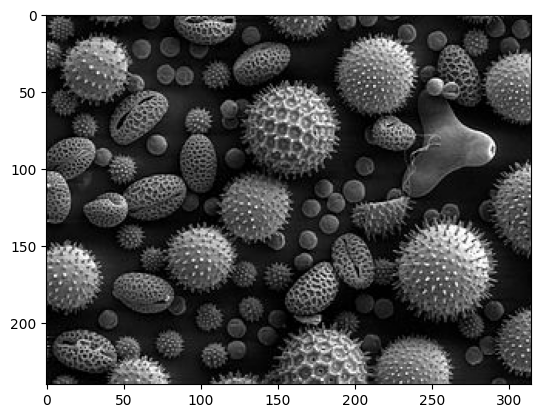

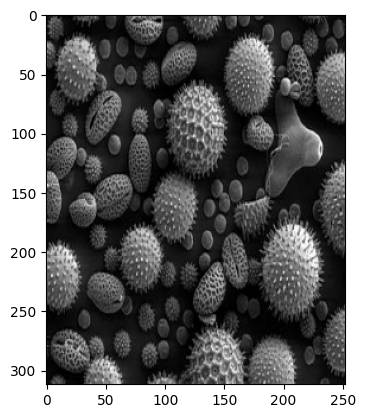

In [19]:

def scale(image, sx,sy):
    h, w, c = image.shape
    new_h = int(h * sy)
    new_w = int(w * sx)
    target = np.zeros((new_h, new_w, c), dtype=image.dtype)
    for y in range(new_h):
        for x in range(new_w):
            src_x = x / sx                                #Mapping target pixel to source pixel
            src_y = y / sy
            x0 = int(math.floor(src_x))
            y0 = int(math.floor(src_y))
            x1 = min(x0 + 1, w - 1)
            y1 = min(y0 + 1, h - 1)
            a = src_x - x0
            b = src_y - y0
            target[y, x] = (                               #Bilinear interpolation
                (1 - a) * (1 - b) * image[y0, x0] +
                a * (1 - b) * image[y0, x1] +
                (1 - a) * b * image[y1, x0] +
                a * b * image[y1, x1]
            )

    return target

image=cv2.imread("cells_scale.png")
scaled_image = scale(image,0.8,1.3)
plt.imshow(image)
plt.show()
plt.imshow(scaled_image)
plt.show()
    